In [2]:
#Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
#from scipy import --

In [4]:
#Loading Data

data = pd.read_excel("Financial Events_Excel.xlsx")
data.head()

,Date,Headline,Source,Market_Event,Market_Index,Index_Change_Percent,Trading_Volume,Sentiment,Sector,Impact_Level,Related_Company,News_Url
0,2025-02-01,Manufacturing PMI data signals economic expansion,Investopedia,Economic Data Release,Nasdaq Composite,-1.29,247.98,Negative,Telecommunications,High,ExxonMobil,https://economictimes.indiatimes.com/news/econ...
1,2025-02-01,Tech Giant's New Product Launch Sparks Sector-...,Yahoo Finance,Economic Data Release,ASX 200,3.42,377.30,Neutral,Finance,Medium,Microsoft,https://www.cnbc.com/2025/10/real-estate-marke...
2,2025-02-01,Semiconductor shortages weigh heavily on tech ...,Bloomberg,Cryptocurrency Regulation,TSX,-4.68,466.30,Positive,Aerospace & Defense,High,Goldman Sachs,https://www.cnbc.com/2025/11/major-merger-deal...
3,2025-02-01,Media and Entertainment companies report a sur...,MarketWatch,Stock Market Crash,Euro Stoxx 50,3.99,411.89,Negative,Transportation,Low,ExxonMobil,https://www.moneycontrol.com/us-markets/sp-500
4,2025-02-01,Mining company stock surges on commodity price...,Bloomberg,Unemployment Rate Announcement,BSE Sensex,4.58,385.19,Negative,Aerospace & Defense,High,Apple Inc.,https://economictimes.indiatimes.com/stocks/bs...


In [5]:
#Data Understanding

In [6]:
data.shape

(3024, 12)

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3024 entries, 0 to 3023
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Date                  3024 non-null   datetime64[ns]
 1   Headline              2876 non-null   object        
 2   Source                3024 non-null   object        
 3   Market_Event          3024 non-null   object        
 4   Market_Index          3024 non-null   object        
 5   Index_Change_Percent  2863 non-null   float64       
 6   Trading_Volume        3024 non-null   float64       
 7   Sentiment             2853 non-null   object        
 8   Sector                3024 non-null   object        
 9   Impact_Level          3024 non-null   object        
 10  Related_Company       3024 non-null   object        
 11  News_Url              2871 non-null   object        
dtypes: datetime64[ns](1), float64(2), object(9)
memory usage: 283.6+ KB


In [8]:
#DATA PRE-PROCESSING

In [9]:
#Data Cleaning

In [10]:
#Duplicates: There is no key column in tis dataset due to which there is no need to search for duplicate values.
#Missing Values: In this dataset, there are major three columns to impute the missing values (Headline, Index_Change_Percent, Sentiment)
#Inconsistent Values: In this dataset, there are no inconsistents in numeric attriutes or date column since their dtypes is already 'float64' and datetime64 respectively. Check the inconsistents in categorical attributes by their unique values.

In [11]:
#Deleting unnecessary column to avoid noise

data = data.drop('News_Url', axis = 1)
data.head()

,Date,Headline,Source,Market_Event,Market_Index,Index_Change_Percent,Trading_Volume,Sentiment,Sector,Impact_Level,Related_Company
0,2025-02-01,Manufacturing PMI data signals economic expansion,Investopedia,Economic Data Release,Nasdaq Composite,-1.29,247.98,Negative,Telecommunications,High,ExxonMobil
1,2025-02-01,Tech Giant's New Product Launch Sparks Sector-...,Yahoo Finance,Economic Data Release,ASX 200,3.42,377.30,Neutral,Finance,Medium,Microsoft
2,2025-02-01,Semiconductor shortages weigh heavily on tech ...,Bloomberg,Cryptocurrency Regulation,TSX,-4.68,466.30,Positive,Aerospace & Defense,High,Goldman Sachs
3,2025-02-01,Media and Entertainment companies report a sur...,MarketWatch,Stock Market Crash,Euro Stoxx 50,3.99,411.89,Negative,Transportation,Low,ExxonMobil
4,2025-02-01,Mining company stock surges on commodity price...,Bloomberg,Unemployment Rate Announcement,BSE Sensex,4.58,385.19,Negative,Aerospace & Defense,High,Apple Inc.


In [12]:
#Inconsistent Values

In [13]:
#Checking data types using .dtypes method

data.dtypes

Date                    datetime64[ns]
Headline                        object
Source                          object
Market_Event                    object
Market_Index                    object
Index_Change_Percent           float64
Trading_Volume                 float64
Sentiment                       object
Sector                          object
Impact_Level                    object
Related_Company                 object
dtype: object

In [14]:
#Checking uniques of categorical attributes

unique1 = data['Headline'].unique()
print(unique1)

['Manufacturing PMI data signals economic expansion'
 "Tech Giant's New Product Launch Sparks Sector-Wide Gains"
 'Semiconductor shortages weigh heavily on tech sector profits'
 'Media and Entertainment companies report a surge in streaming revenue'
 'Mining company stock surges on commodity price boom'
 'Retail sales report surpasses all forecasts'
 'Consumer confidence index reaches a decade high'
 'Merger talks between two banks fall through'
 'Banking stocks dip after a major scandal is revealed'
 'Market sentiment turns positive on vaccine trial results'
 'Geopolitical ceasefire prompts a broad market recovery'
 'E-commerce earnings report beats all analyst expectations'
 'Utilities sector remains stable during market fluctuations'
 'Massive stock buyback program announced by a consumer goods company'
 'Government subsidy program gives a lift to the agriculture sector'
 'Consumer Discretionary stocks outperform as spending increases'
 'Quarterly report shows surprising losses for 

In [15]:
#Counting total no. of unique values in Headline attribute

print(data['Headline'].nunique())

50


In [16]:
unique2 = data['Source'].unique()
print(unique2)

['Investopedia' 'Yahoo Finance' 'Bloomberg' 'MarketWatch'
 'Wall Street Journal' 'Times of India' 'Mint' 'Seeking Alpha'
 'The Hindu Business Line' 'Reuters' 'The Motley Fool' 'Economic Times'
 'Business Standard' 'Financial Times' "Barron's" 'CNBC' 'The Economist'
 'Forbes']


In [17]:
unique3 = data['Market_Event'].unique()
print(unique3)

['Economic Data Release' 'Cryptocurrency Regulation' 'Stock Market Crash'
 'Unemployment Rate Announcement' 'Consumer Confidence Report'
 'Regulatory Changes' 'Commodity Price Shock' 'Interest Rate Change'
 'Corporate Earnings Report' 'Geopolitical Event' 'Currency Devaluation'
 'Bond Market Fluctuation' 'Central Bank Meeting'
 'Government Policy Announcement' 'Supply Chain Disruption' 'Market Rally'
 'Trade Tariffs Announcement' 'IPO Launch' 'Inflation Data Release'
 'Major Merger/Acquisition']


In [18]:
unique4 = data['Market_Index'].unique()
unique5 = data['Sentiment'].unique()
unique6 = data['Sector'].unique()
unique7 = data['Impact_Level'].unique()
unique8 = data['Related_Company'].unique()

print(unique4)
print(unique5)
print(unique6)
print(unique7)
print(unique8)

['Nasdaq Composite' 'ASX 200' 'TSX' 'Euro Stoxx 50' 'BSE Sensex' 'DAX'
 'NSE Nifty' 'Shanghai Composite' 'Hang Seng' 'S&P 500' 'KOSPI'
 'Nikkei 225' 'S&P/TSX Composite' 'IBOVESPA' 'Russell 2000' 'CAC 40'
 'Dow Jones' 'FTSE 100']
['Negative' 'Neutral' 'Positive' nan]
['Telecommunications' 'Finance' 'Aerospace & Defense' 'Transportation'
 'Media & Entertainment' 'Retail' 'Utilities' 'Industrials'
 'Consumer Goods' 'Materials' 'Energy' 'Pharmaceuticals' 'Construction'
 'Real Estate' 'Technology' 'Automotive' 'Healthcare' 'Agriculture']
['High' 'Medium' 'Low']
['ExxonMobil' 'Microsoft' 'Goldman Sachs' 'Apple Inc.' 'Tata Motors'
 'JP Morgan Chase' 'Boeing' 'Reliance Industries' 'Tesla'
 'Samsung Electronics']


In [19]:
#Missing values

missing = data.isnull().sum()
print(missing)

Date                      0
Headline                148
Source                    0
Market_Event              0
Market_Index              0
Index_Change_Percent    161
Trading_Volume            0
Sentiment               171
Sector                    0
Impact_Level              0
Related_Company           0
dtype: int64


In [20]:
#Imputation

from sklearn.impute import SimpleImputer

impute1 = SimpleImputer(strategy = 'mean')
impute1.fit(data[['Index_Change_Percent']])
data[['Index_Change_Percent']] = impute1.transform(data[['Index_Change_Percent']])

impute2 = SimpleImputer(strategy = 'most_frequent')
impute2.fit(data[['Sentiment']])
data[['Sentiment']] = impute2.transform(data[['Sentiment']])

impute3 = SimpleImputer(strategy = 'most_frequent')
impute3.fit(data[['Headline']])
data[['Headline']] = impute3.transform(data[['Headline']])

In [21]:
#Checking the missing values if any, after Imputation

print(data.isnull().sum())

Date                    0
Headline                0
Source                  0
Market_Event            0
Market_Index            0
Index_Change_Percent    0
Trading_Volume          0
Sentiment               0
Sector                  0
Impact_Level            0
Related_Company         0
dtype: int64


In [22]:
#Summarizing Descriptive Statistics

data.describe()

,Date,Index_Change_Percent,Trading_Volume
count,3024,3024.000000,3024.000000
mean,2025-05-09 07:43:48.571428608,-0.021753,249.037917
min,2025-02-01 00:00:00,-4.990000,1.060000
25%,2025-03-23 00:00:00,-2.310000,120.427500
50%,2025-05-09 00:00:00,-0.021753,244.020000
75%,2025-06-26 00:00:00,2.330000,377.000000
max,2025-08-14 00:00:00,5.000000,499.830000
std,NaN,2.775005,145.497932


In [23]:
#Exploratory Data Analysis

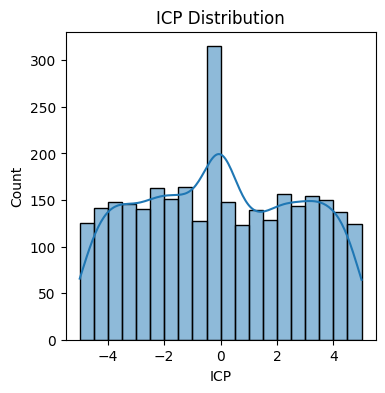

In [24]:
#Visualizing Index_Change_Percent Distribution

plt.figure(figsize = (4,4))
sns.histplot(data['Index_Change_Percent'], bins=20, kde=True)
plt.title('ICP Distribution')
plt.xlabel('ICP')
plt.show()

#Market mostly is stable since the values are concentrated mostly around 0%

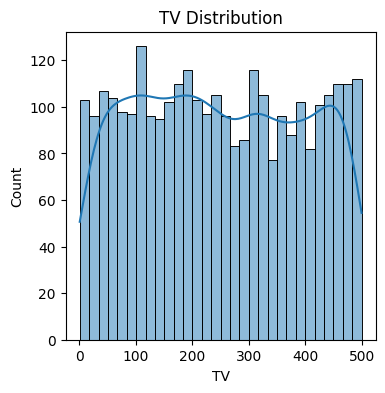

In [25]:
#Visualizing Trading_Volume Distribution

plt.figure(figsize = (4,4))
sns.histplot(data['Trading_Volume'], bins=30, kde=True)
plt.title('TV Distribution')
plt.xlabel('TV')
plt.show()

#Both low and high participation exist evenly

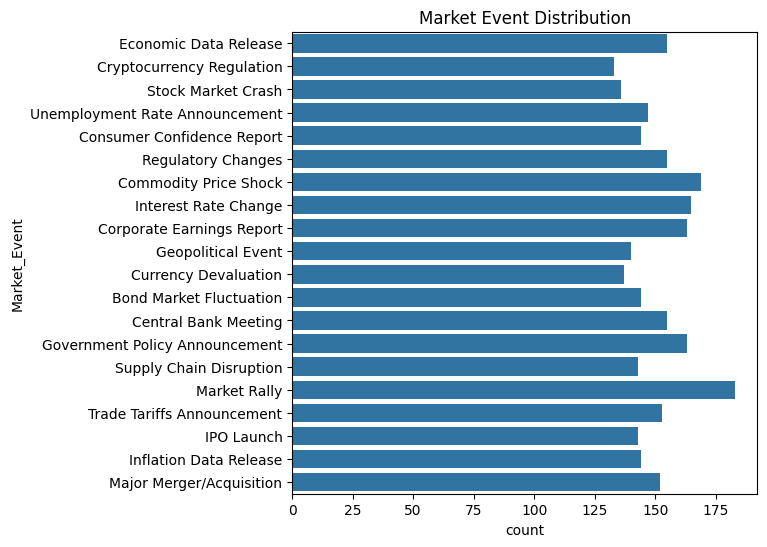

In [26]:
#Market Event Distribution (Count Analysis)

plt.figure(figsize=(6,6))
sns.countplot(y='Market_Event', data=data)
plt.title("Market Event Distribution")
plt.show()

#Events have same frequencies, but slighlty higher for Market Rally, Commodity Price Shock, Interest Rate Change

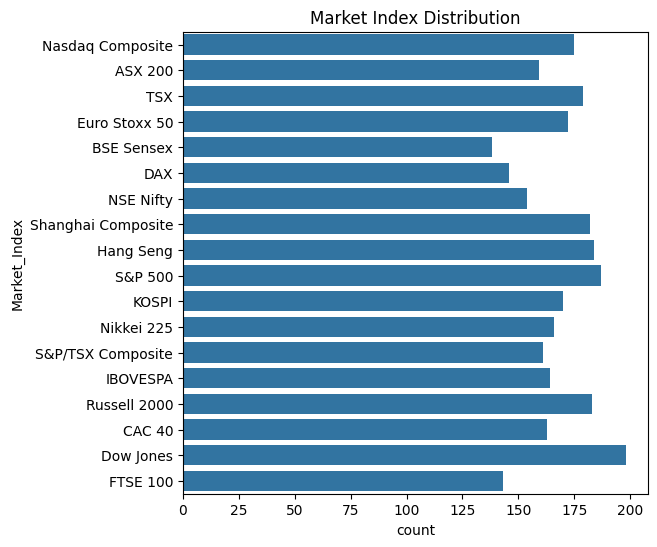

In [27]:
#Market Index Distribution (Count Analysis)

plt.figure(figsize = (6,6))
sns.countplot(y = 'Market_Index', data = data)
plt.title("Market Index Distribution")
plt.show()

#Slighlty, U.S. market is affected the most

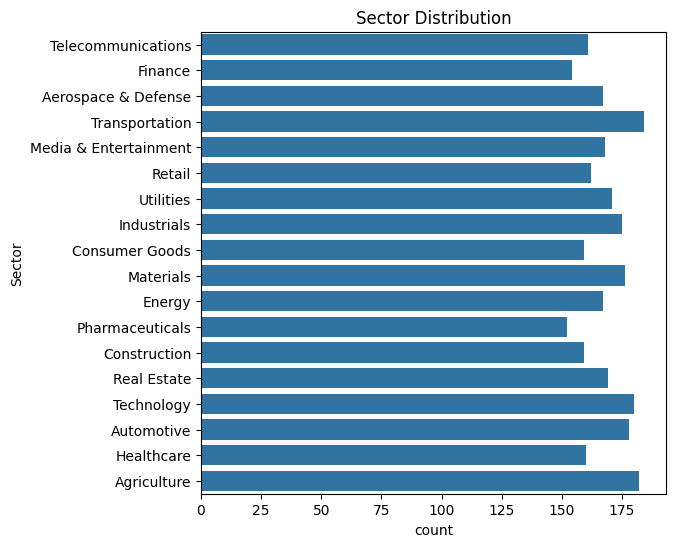

In [28]:
#Sector Distribution (Count Analysis)

plt.figure(figsize = (6,6))
sns.countplot(y='Sector', data=data)
plt.title("Sector Distribution")
plt.show()

#All sectors are evenly affected

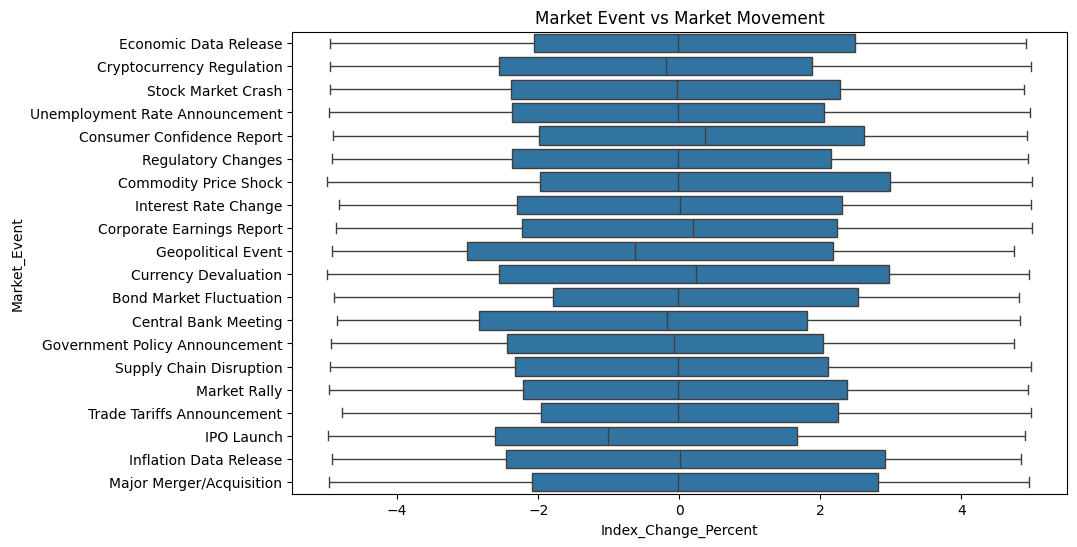

In [29]:
#Market Event vs Market Movement (ICP)

plt.figure(figsize=(10,6))
sns.boxplot(y='Market_Event', x='Index_Change_Percent', data=data)
plt.title("Market Event vs Market Movement")
plt.show()

#Most events cause neutral effect or moderate change on the market
#Same events can cause both gain and loss

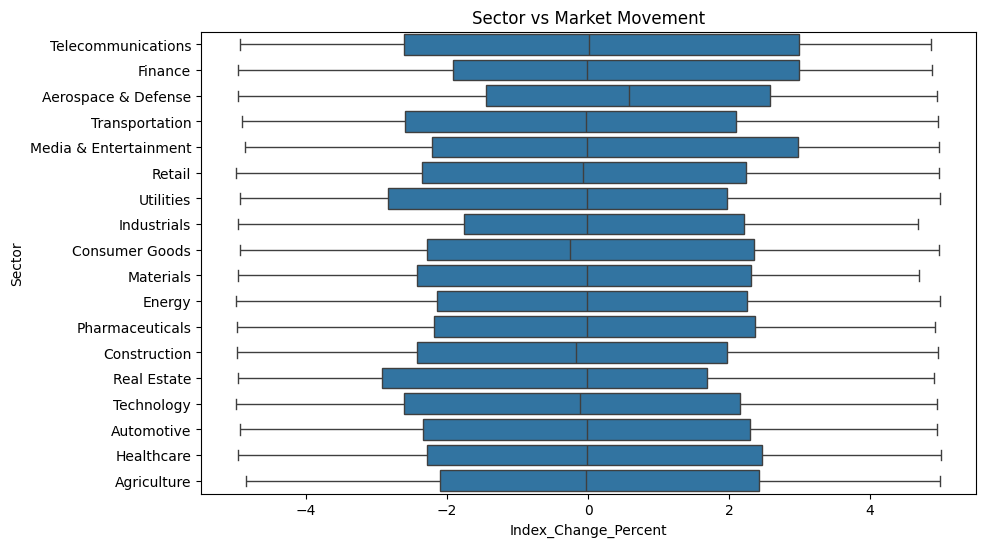

In [30]:
#Sector vs Market Movement

plt.figure(figsize=(10,6))
sns.boxplot(y='Sector', x='Index_Change_Percent', data=data)
plt.title("Sector vs Market Movement")
plt.show()

#Most sectors have neutral average movement
#No sector consistently underperforms or outperforms

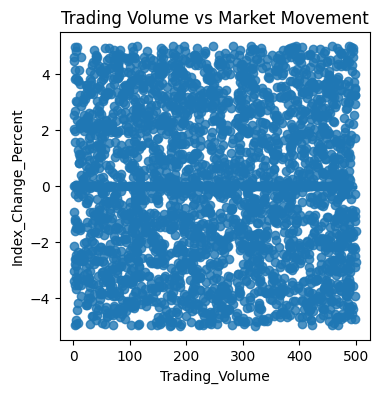

In [31]:
#Scatter Plot: Trading Volume vs Market Movement

plt.figure(figsize=(4,4))
sns.regplot(x='Trading_Volume', y='Index_Change_Percent', data=data)
plt.title("Trading Volume vs Market Movement")
plt.show()

#TV has no clear upward or downward trend (no clear relationship) with ICP

<function matplotlib.pyplot.show(close=None, block=None)>

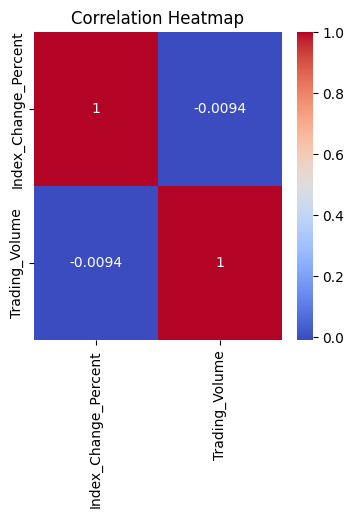

In [32]:
#Correlation Heatmap (numeric attributes: Trading Volume vs Index Change Percent)

plt.figure(figsize=(4,4))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show

#r = 0 (no linear relationship)

In [33]:
#Significant Analysis between Market Event and Impact Level

import scipy
from scipy import stats
from scipy.stats import chi2_contingency

cross_tab = pd.crosstab(data['Market_Event'], data['Impact_Level'])

ci, p, dof, expected = chi2_contingency(cross_tab)

if p<0.05:
    print("There is a significant relationship between Market Event and Impact Level")
else:
    print("There is no significant relationship")

There is a significant relationship between Market Event and Impact Level


In [34]:
#Significant Analysis between Market Event and Sentiment

cross_tab2 = pd.crosstab(data['Market_Event'], data['Sentiment'])

ci, p, dof, expected = chi2_contingency(cross_tab2)

if p<0.05:
    print("There is a significant relationship between Market Event and Sentiment")
else:
    print("There is no significant relationship")

There is no significant relationship


In [35]:
#Significant Analysis between Sector and Sentiment

cross_tab3 = pd.crosstab(data['Sector'], data['Sentiment'])

ci, p, dof, expected = chi2_contingency(cross_tab3)

if p<0.05:
    print("There is a significant relationship between Sector and Sentiment")
else:
    print("There is no significant relationship")

There is no significant relationship


In [36]:
#Significant Analysis between Market Event and Sector

cross_tab4 = pd.crosstab(data['Market_Event'], data['Sector'])

ci, p, dof, expected = chi2_contingency(cross_tab4)

if p<0.05:
    print("There is a significant relationship between Market Event and Sector")
else:
    print("There is no significant relationship")

There is no significant relationship


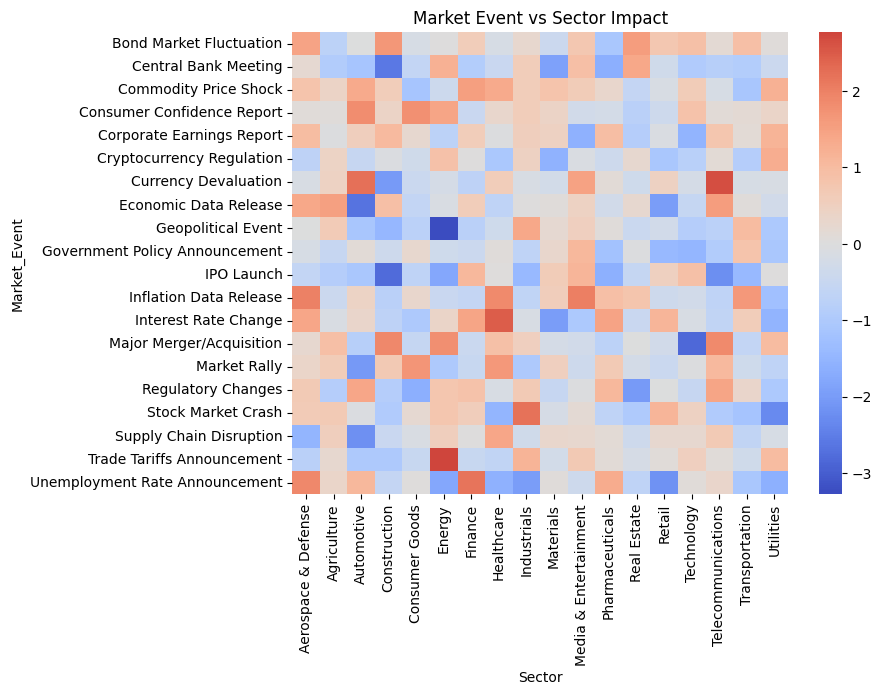

In [37]:
#Visualizing the effect of Market Event on each Sector

pivot_table = data.pivot_table(
    values='Index_Change_Percent',
    index='Market_Event',
    columns = 'Sector',
    aggfunc='mean'
)

plt.figure(figsize=(8,6))
sns.heatmap(pivot_table, cmap='coolwarm', center=0)
plt.title("Market Event vs Sector Impact")
plt.show()

#red: positive impact, blue:negative impact

In [38]:
#NEED OF ML MODEL (PREDICTIVE MODELLING)

#The exploratory data analysis reveals that market movements are influenced by a combination of factors rather than any single variable.
#While categorical variables such as market events provide contextual information, numerical variables like trading volume show minimal direct correlation with index changes.

#These findings highlight the complexity of financial markets and justify the use of machine learning models to capture non-linear relationships among multiple features.

In [39]:
#Data Transformation

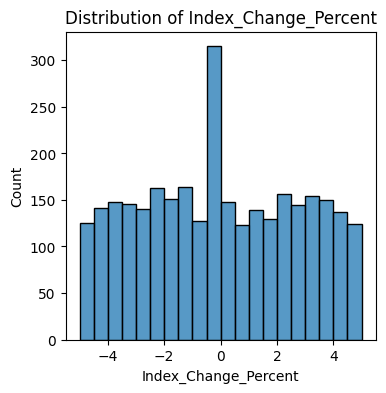

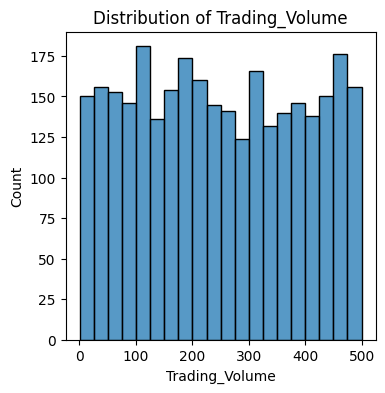

In [40]:
#Checking the distribution of data points of numerical attributes: (Histogram, KDE Plot, Boxplot, skew function, )

#HISTOGRAM

num_cols = ['Index_Change_Percent', 'Trading_Volume']

for col in num_cols:
    plt.figure(figsize=(4,4))
    sns.histplot(data[col], bins = 20)
    plt.title(f"Distribution of {col}")
    plt.show()

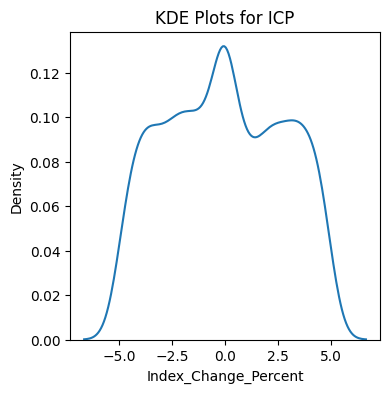

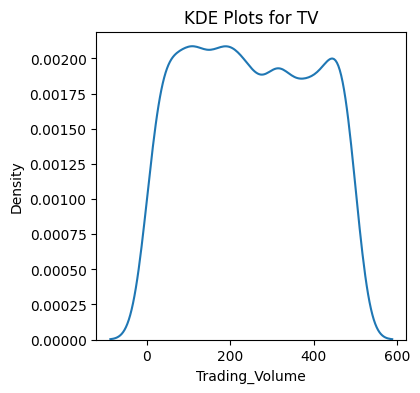

In [41]:
#KDE PLOT

fig, axes = plt.subplots(1, 1, figsize = (4,4))
sns.kdeplot(data['Index_Change_Percent'])
axes.set_title('KDE Plots for ICP')
plt.show()

fig, axes = plt.subplots(1, 1, figsize = (4,4))
sns.kdeplot(data['Trading_Volume'])
axes.set_title('KDE Plots for TV')
plt.show()

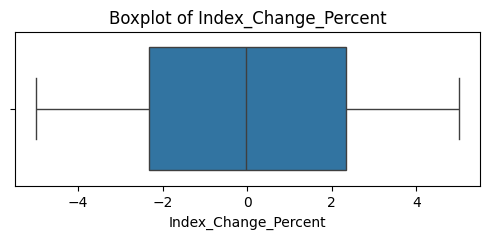

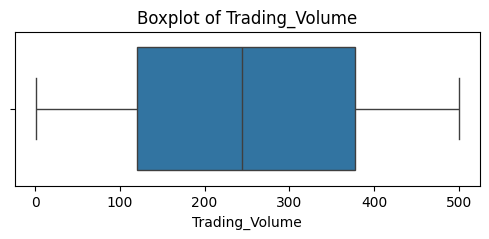

In [42]:
#BOXPLOT

for col in num_cols:
    plt.figure(figsize=(6,2))
    sns.boxplot(x = data[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

#Since, there are no dots outside whiskers: no outliers

In [43]:
#SKEW FUNCTION

data[['Index_Change_Percent', 'Trading_Volume']].skew()

#Since the skew values for both numeric attributes are near to zero: Normal Distribution

Index_Change_Percent    0.021755
Trading_Volume          0.041092
dtype: float64

In [44]:
#FEATURE ENGINEERING

In [45]:
data.head()

,Date,Headline,Source,Market_Event,Market_Index,Index_Change_Percent,Trading_Volume,Sentiment,Sector,Impact_Level,Related_Company
0,2025-02-01,Manufacturing PMI data signals economic expansion,Investopedia,Economic Data Release,Nasdaq Composite,-1.29,247.98,Negative,Telecommunications,High,ExxonMobil
1,2025-02-01,Tech Giant's New Product Launch Sparks Sector-...,Yahoo Finance,Economic Data Release,ASX 200,3.42,377.30,Neutral,Finance,Medium,Microsoft
2,2025-02-01,Semiconductor shortages weigh heavily on tech ...,Bloomberg,Cryptocurrency Regulation,TSX,-4.68,466.30,Positive,Aerospace & Defense,High,Goldman Sachs
3,2025-02-01,Media and Entertainment companies report a sur...,MarketWatch,Stock Market Crash,Euro Stoxx 50,3.99,411.89,Negative,Transportation,Low,ExxonMobil
4,2025-02-01,Mining company stock surges on commodity price...,Bloomberg,Unemployment Rate Announcement,BSE Sensex,4.58,385.19,Negative,Aerospace & Defense,High,Apple Inc.


In [47]:
#1. Creating new features: Market Direction (Target for Calssification model)

data['Market_Direction'] = np.where(
    data['Index_Change_Percent'] > 0.5, "Up", (np.where(
        data['Index_Change_Percent'] < -0.5, "Down", "Neutral"
    )
                                              )
)

In [48]:
data.head()

,Date,Headline,Source,Market_Event,Market_Index,Index_Change_Percent,Trading_Volume,Sentiment,Sector,Impact_Level,Related_Company,Market_Direction
0,2025-02-01,Manufacturing PMI data signals economic expansion,Investopedia,Economic Data Release,Nasdaq Composite,-1.29,247.98,Negative,Telecommunications,High,ExxonMobil,Down
1,2025-02-01,Tech Giant's New Product Launch Sparks Sector-...,Yahoo Finance,Economic Data Release,ASX 200,3.42,377.30,Neutral,Finance,Medium,Microsoft,Up
2,2025-02-01,Semiconductor shortages weigh heavily on tech ...,Bloomberg,Cryptocurrency Regulation,TSX,-4.68,466.30,Positive,Aerospace & Defense,High,Goldman Sachs,Down
3,2025-02-01,Media and Entertainment companies report a sur...,MarketWatch,Stock Market Crash,Euro Stoxx 50,3.99,411.89,Negative,Transportation,Low,ExxonMobil,Up
4,2025-02-01,Mining company stock surges on commodity price...,Bloomberg,Unemployment Rate Announcement,BSE Sensex,4.58,385.19,Negative,Aerospace & Defense,High,Apple Inc.,Up


In [49]:
data['Market_Direction'].value_counts()

Market_Direction
Down       1304
Up         1256
Neutral     464
Name: count, dtype: int64

In [50]:
#2. Extracting new features: Month and Day of the Week from the Date column

#data['Date'] = pd.to_datetime(data['Date'])

data['Month'] = data['Date'].dt.month
data['Week_Day'] = data['Date'].dt.dayofweek

In [51]:
data.tail()

,Date,Headline,Source,Market_Event,Market_Index,Index_Change_Percent,Trading_Volume,Sentiment,Sector,Impact_Level,Related_Company,Market_Direction,Month,Week_Day
3019,2025-08-14,Merger talks between two banks fall through,CNBC,Corporate Earnings Report,S&P 500,1.360000,144.64,Neutral,Healthcare,High,ExxonMobil,Up,8,3
3020,2025-08-14,Financial services stocks rally on strong prof...,MarketWatch,Major Merger/Acquisition,Euro Stoxx 50,-2.720000,86.59,Positive,Automotive,Low,Tesla,Down,8,3
3021,2025-08-14,Consumer Discretionary stocks outperform as sp...,Financial Times,Central Bank Meeting,Hang Seng,3.770000,134.13,Neutral,Industrials,High,Reliance Industries,Up,8,3
3022,2025-08-14,Quarterly report shows surprising losses for r...,Seeking Alpha,Cryptocurrency Regulation,DAX,0.330000,461.74,Positive,Agriculture,High,Samsung Electronics,Neutral,8,3
3023,2025-08-14,Geopolitical ceasefire prompts a broad market ...,Forbes,Corporate Earnings Report,Euro Stoxx 50,-0.021753,255.04,Negative,Automotive,Medium,Tesla,Neutral,8,3


In [52]:
data['Week_Day'].unique()

array([5, 6, 0, 1, 2, 3, 4], dtype=int32)

In [53]:
def dayofweek(y):
    if y == 0:
        return"Mon"
    elif y == 1:
        return"Tue"
    elif y == 2:
        return"Wed"
    elif y == 3:
        return"Thu"
    elif y == 4:
        return"Fri"
    elif y == 5:
        return"Sat"
    else:
        return"Sun"

data['Day_of_Week'] = data['Week_Day'].apply(dayofweek)

In [54]:
encoded_data = data.drop(['Date', 'Headline', 'Day_of_Week'], axis=1)
encoded_data.head()

,Source,Market_Event,Market_Index,Index_Change_Percent,Trading_Volume,Sentiment,Sector,Impact_Level,Related_Company,Market_Direction,Month,Week_Day
0,Investopedia,Economic Data Release,Nasdaq Composite,-1.29,247.98,Negative,Telecommunications,High,ExxonMobil,Down,2,5
1,Yahoo Finance,Economic Data Release,ASX 200,3.42,377.30,Neutral,Finance,Medium,Microsoft,Up,2,5
2,Bloomberg,Cryptocurrency Regulation,TSX,-4.68,466.30,Positive,Aerospace & Defense,High,Goldman Sachs,Down,2,5
3,MarketWatch,Stock Market Crash,Euro Stoxx 50,3.99,411.89,Negative,Transportation,Low,ExxonMobil,Up,2,5
4,Bloomberg,Unemployment Rate Announcement,BSE Sensex,4.58,385.19,Negative,Aerospace & Defense,High,Apple Inc.,Up,2,5


In [55]:
#3. Encoding: Convert categorical to numeric values

from sklearn.preprocessing import LabelEncoder

cat_col = ['Source', 'Market_Event', 'Market_Index', 'Sentiment', 'Sector', 'Related_Company']

encode = LabelEncoder()
for col in cat_col:
    encoded_data[col] = encode.fit_transform(encoded_data[col])

encoded_data.head()

,Source,Market_Event,Market_Index,Index_Change_Percent,Trading_Volume,Sentiment,Sector,Impact_Level,Related_Company,Market_Direction,Month,Week_Day
0,7,7,11,-1.29,247.98,0,15,High,2,Down,2,5
1,17,7,0,3.42,377.30,1,6,Medium,5,Up,2,5
2,1,5,17,-4.68,466.30,2,0,High,3,Down,2,5
3,8,16,5,3.99,411.89,0,16,Low,2,Up,2,5
4,1,19,1,4.58,385.19,0,0,High,0,Up,2,5


In [56]:
#4. Mapping: Manual encoding for Imapct level

mapping1 = {'Low':0, 'Medium':1, 'High':2}
encoded_data['Impact_Level'] = encoded_data['Impact_Level'].map(mapping1)

encoded_data.head()

,Source,Market_Event,Market_Index,Index_Change_Percent,Trading_Volume,Sentiment,Sector,Impact_Level,Related_Company,Market_Direction,Month,Week_Day
0,7,7,11,-1.29,247.98,0,15,2,2,Down,2,5
1,17,7,0,3.42,377.30,1,6,1,5,Up,2,5
2,1,5,17,-4.68,466.30,2,0,2,3,Down,2,5
3,8,16,5,3.99,411.89,0,16,0,2,Up,2,5
4,1,19,1,4.58,385.19,0,0,2,0,Up,2,5


In [57]:
encoded_data

,Source,Market_Event,Market_Index,Index_Change_Percent,Trading_Volume,Sentiment,Sector,Impact_Level,Related_Company,Market_Direction,Month,Week_Day
0,7,7,11,-1.290000,247.98,0,15,2,2,Down,2,5
1,17,7,0,3.420000,377.30,1,6,1,5,Up,2,5
2,1,5,17,-4.680000,466.30,2,0,2,3,Down,2,5
3,8,16,5,3.990000,411.89,0,16,0,2,Up,2,5
4,1,19,1,4.580000,385.19,0,0,2,0,Up,2,5
...,...,...,...,...,...,...,...,...,...,...,...,...
3019,3,4,14,1.360000,144.64,1,7,2,2,Up,8,3
3020,8,13,5,-2.720000,86.59,2,2,0,9,Down,8,3
3021,5,1,7,3.770000,134.13,1,8,2,6,Up,8,3
3022,11,5,3,0.330000,461.74,2,1,2,7,Neutral,8,3


In [58]:
encoded_data2 = encoded_data

In [59]:
#Converting Market Direction classes into numeric labels isnce XGBoost model neend numeric classes not categorical class labels.

mapping2 = {'Up':2.0, 'Down':0.0, 'Neutral':1.0}
encoded_data2['XGB_Market_Direction'] = encoded_data2['Market_Direction'].map(mapping2)

encoded_data2.head()

,Source,Market_Event,Market_Index,Index_Change_Percent,Trading_Volume,Sentiment,Sector,Impact_Level,Related_Company,Market_Direction,Month,Week_Day,XGB_Market_Direction
0,7,7,11,-1.29,247.98,0,15,2,2,Down,2,5,0.0
1,17,7,0,3.42,377.30,1,6,1,5,Up,2,5,2.0
2,1,5,17,-4.68,466.30,2,0,2,3,Down,2,5,0.0
3,8,16,5,3.99,411.89,0,16,0,2,Up,2,5,2.0
4,1,19,1,4.58,385.19,0,0,2,0,Up,2,5,2.0


In [60]:
#DATA MINING

In [61]:
#1. Selecting Features and Target

x = encoded_data[['Source', 'Market_Event', 'Market_Index', 'Trading_Volume', 'Sentiment', 'Sector', 'Impact_Level', 'Month', 'Week_Day']]
c_y = encoded_data['Market_Direction']
r_y = encoded_data['Index_Change_Percent']

In [62]:
#2. Scaling: Tarding Volume
#It's not required for the Tree-basd models (Random Forest or XGBoost) since scale of values do not affect them, which we will use in our project.

#3. Dimensionality Reduction
#We already have less features and tree-based models automatically handle irrelevant features. And applying PCA will reduce interpretability.

In [63]:
#4. Train and Test Split

from sklearn.model_selection import train_test_split

#Classification Model

c_x_train, c_x_test, c_y_train, c_y_test = train_test_split(
    x,
    c_y,
    test_size = 0.2,
    random_state = 42,
    stratify = c_y
)

#Regression Model

r_x_train, r_x_test, r_y_train, r_y_test = train_test_split(
    x,
    r_y,
    test_size = 0.2,
    random_state = 42
)

In [64]:
#CLASSIFICATION MODEL: Predict Market Direction

In [65]:
#1. Random Forest C.M.

#Training the model and making prediction

from sklearn.ensemble import RandomForestClassifier

c_model = RandomForestClassifier(
    class_weight = 'balanced',
    random_state = 42
)
c_model.fit(c_x_train, c_y_train)
c_pred = c_model.predict(c_x_test)

In [66]:
#Evaluating the model

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy Score: ", accuracy_score(c_y_test, c_pred))
print("\nConfusion Matrix: \n", confusion_matrix(c_y_test, c_pred))
print("\nClassification Report: \n", classification_report(c_y_test, c_pred))

#Improved the model with Target threshold and class_weight

Accuracy Score:  0.41652892561983473

Confusion Matrix: 
 [[156   6  99]
 [ 48   1  44]
 [156   0  95]]

Classification Report: 
               precision    recall  f1-score   support

        Down       0.43      0.60      0.50       261
     Neutral       0.14      0.01      0.02        93
          Up       0.40      0.38      0.39       251

    accuracy                           0.42       605
   macro avg       0.33      0.33      0.30       605
weighted avg       0.37      0.42      0.38       605



In [67]:
#REGRESSION MODEL: Predict Index_Change_Percent

In [68]:
#1. Random Forest R.M.

#Train the model and make predictions

from sklearn.ensemble import RandomForestRegressor

r_model = RandomForestRegressor(
    random_state = 42
)
r_model.fit(r_x_train, r_y_train)
r_pred = r_model.predict(r_x_test)

In [69]:
#Evaluate the model

from sklearn.metrics import mean_squared_error, r2_score

print("MSE: ", mean_squared_error(r_y_test, r_pred))
print("\nR2 Score: ", r2_score(r_y_test, r_pred))

MSE:  8.253112936737597

R2 Score:  -0.05084811747342277
